## QML-FAST: 3-field example (noise-bias-subtracted)

Full QML pipeline on 3 correlated Gaussian fields at nside=32:
1. Build pixel covariance (signal + white pixel noise), mask, and deproject low-\ell modes
2. Test Sherman-Woodbury mode deprojection against the existing projector/pseudo-inverse construction
3. Compute Fisher matrix with `getF` for both inverse-covariance constructions
4. Compute noise bias $b_A = \tfrac12\mathrm{Tr}(M\,P_A\,M\,\mathbb{N})$ for both methods
5. Run the same MC sims through both estimators and compare estimates/error bars
6. Plot the Woodbury estimates and compare analytic $F^{-1}$ to empirical error bars

(Note that in this notebook, we are doing some sanity checks that are expensive to compute. If the notebook takes too long to run - reduce the nside to 16)

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
import scipy as sp
from tqdm import tqdm

from utilities import *
from qmlfast import *

### 1. Simulation setup

In [2]:
nside = 32
lmax  = 3*nside - 1
n_ell = 3*nside
ell   = np.arange(n_ell).astype(float)

S_aa = (ell+1)**(-2)
S_bb = 3*(ell+1)**(-2)
S_cc = 5*(ell+1)**(-2)
S_ab = np.sqrt(S_aa*S_bb)
S_ca = np.sqrt(S_aa*S_cc)
S_bc = np.sqrt(S_bb*S_cc)

N_a, N_b, N_c = 5e-2, 5e-2, 1e-2
A_ab, A_ca, A_bc = 0.3, 0.5, 0.5

# Signal cross-spectra (with correlation amplitudes)
S_ab_fid = A_ab * S_ab
S_ca_fid = A_ca * S_ca
S_bc_fid = A_bc * S_bc

# Total spectra (for reference / old-style sims)
C_aa = S_aa + N_a
C_bb = S_bb + N_b
C_cc = S_cc + N_c
C_ab = A_ab * S_ab
C_ca = A_ca * S_ca
C_bc = A_bc * S_bc

Nf = 3

Sky fraction: 0.47


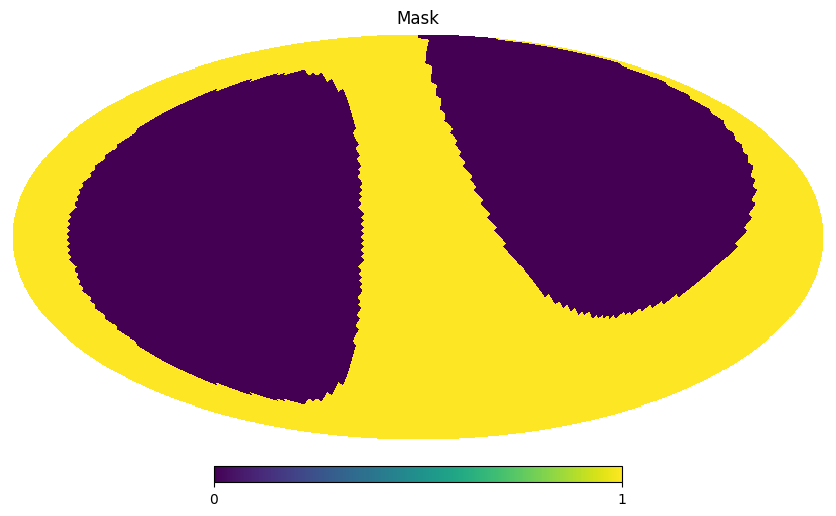

In [3]:
# Mask
vec = hp.ang2vec(np.pi / 2, np.pi/2)
ipix_disc = hp.query_disc(nside=nside, vec=vec, radius=np.radians(65))
vec1 = hp.ang2vec(np.pi / 3, 3*np.pi/2)
ipix_disc1 = hp.query_disc(nside=nside, vec=vec1, radius=np.radians(59))

mask = np.ones(hp.nside2npix(nside))
mask[ipix_disc] = 0.
mask[ipix_disc1] = 0.
hp.mollview(mask, title='Mask')
print(f'Sky fraction: {mask.mean():.2f}')

In [4]:
def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

theta, phi = theta_phi(nside)
theta = theta[mask==1]
phi = phi[mask==1]
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

Np = len(theta)
omega_pix = 4 * np.pi / hp.nside2npix(nside)

# Pixel-space noise covariance (uncorrelated between fields)
N_pix = np.zeros([Nf*Np, Nf*Np])
N_pix[block_np(0, 0, Np)] = np.eye(Np) * N_a / omega_pix
N_pix[block_np(1, 1, Np)] = np.eye(Np) * N_b / omega_pix
N_pix[block_np(2, 2, Np)] = np.eye(Np) * N_c / omega_pix
N_diag = np.array([N_a, N_b, N_c])

# Fiducial pixel covariance: signal (band-limited) + white pixel noise.
# Keep this unprojected; the two deprojection methods below both start from it.
large_cov = np.zeros([Nf*Np, Nf*Np])
large_cov[block_np(0, 0, Np)] = get_pix_cov_block(S_aa,     Pl_ij, 0, n_ell) + N_pix[block_np(0, 0, Np)]
large_cov[block_np(0, 1, Np)] = get_pix_cov_block(S_ab_fid, Pl_ij, 0, n_ell)
large_cov[block_np(0, 2, Np)] = get_pix_cov_block(S_ca_fid, Pl_ij, 0, n_ell)
large_cov[block_np(1, 0, Np)] = large_cov[block_np(0, 1, Np)].T
large_cov[block_np(1, 1, Np)] = get_pix_cov_block(S_bb,     Pl_ij, 0, n_ell) + N_pix[block_np(1, 1, Np)]
large_cov[block_np(1, 2, Np)] = get_pix_cov_block(S_bc_fid, Pl_ij, 0, n_ell)
large_cov[block_np(2, 0, Np)] = large_cov[block_np(0, 2, Np)].T
large_cov[block_np(2, 1, Np)] = large_cov[block_np(1, 2, Np)].T
large_cov[block_np(2, 2, Np)] = get_pix_cov_block(S_cc,     Pl_ij, 0, n_ell) + N_pix[block_np(2, 2, Np)]

Pl_ij: 100%|█████████████████████████████████████████████████████████| 96/96 [00:24<00:00,  3.94it/s]


In [5]:
#sanity check to make sure that the covariance is not ill-defined.
#Note that this takes longer time dependent on the configuration
#print(f'Np = {Np}, cond(C) = {np.linalg.cond(large_cov):.2e}')

### 2. Mode deprojection ($\ell < \ell_{\min}$)

The notebook keeps the original projector/pseudo-inverse construction as a reference, then tests the alternate Sherman-Woodbury replacement
$M = C^{-1} - C^{-1}Z(Z^T C^{-1}Z)^{-1}Z^T C^{-1}$.
Here `Z_raw` deliberately uses the non-orthogonal real spherical-harmonic columns, so the check also exercises the claim that no QR orthogonalization is required.


In [6]:
ell0 = 4

# Existing reference construction: orthonormalize low-ell modes, project C, regularize
# the removed subspace, invert, and project the inverse back onto the retained subspace.
Z_orth, pi = construct_Z_and_pi(theta, phi, ell0=ell0, lmax=lmax)
C_projected = large_cov.copy()
for i in range(Nf):
    for j in range(Nf):
        cov_block = C_projected[block_np(i, j, Np)]
        C_projected[block_np(i, j, Np)] = pi @ cov_block @ pi.T

eta = 1e-1
ZZT_block = sp.linalg.block_diag(*[Z_orth @ Z_orth.T] * Nf)
M_pinv = np.linalg.inv(C_projected + eta * ZZT_block)
for i in range(Nf):
    for j in range(Nf):
        inv_block = M_pinv[block_np(i, j, Np)]
        M_pinv[block_np(i, j, Np)] = pi @ inv_block @ pi.T
M_pinv = 0.5 * (M_pinv + M_pinv.T)

# Alternate construction: use the raw, non-orthogonal low-ell columns directly.
large_cov_inv = np.linalg.inv(large_cov)
Z_raw = low_ell_mode_matrix(theta, phi, ell0)
Z_all = sp.linalg.block_diag(*[Z_raw] * Nf)
M_woodbury = deproject_inverse_woodbury(large_cov_inv, Z_all)

rel_M = np.linalg.norm(M_woodbury - M_pinv) / np.linalg.norm(M_pinv)
null_norm = np.linalg.norm(M_woodbury @ Z_all) / np.linalg.norm(Z_all)
print(f'raw Z shape: {Z_raw.shape} per field, {Z_all.shape} multifield')
#check the difference between two is 0
print(f'||M_woodbury - M_pinv|| / ||M_pinv|| = {rel_M:.3e}')
#check if Z actually kills unwanted modes
print(f'||M_woodbury Z|| / ||Z|| = {null_norm:.3e}')

# Use the alternate deprojection for the QML pipeline below.
M = M_woodbury

# Drop large temporaries that are no longer needed downstream.
del C_projected, ZZT_block, Z_all

raw Z shape: (5748, 16) per field, (17244, 48) multifield
||M_woodbury - M_pinv|| / ||M_pinv|| = 5.079e-15
||M_woodbury Z|| / ||Z|| = 3.003e-17


### 3. Fisher matrix

In [7]:
F_idx = np.array([(i, j, l) for l in range(n_ell)
                  for i in range(Nf) for j in range(i, Nf)])
C_map = np.ones([Nf, Nf])
n_pairs = Nf * (Nf + 1) // 2  # 6

Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)
F = getF(Y_r_all, M, F_idx, Nf, Np, C_map)
print(f'F shape: {F.shape}')

# Sanity: deprojected modes should have F ~ 0
null_block = F[np.ix_(F_idx[:,2]<ell0, F_idx[:,2]<ell0)]
print(f'F[ell<{ell0}] max = {np.max(np.abs(null_block)):.1e}  (should be ~0)')

VCinvV: 100%|██████████████████████████████████████████████████████████| 6/6 [00:16<00:00,  2.73s/it]


F shape: (576, 576)
F[ell<4] max = 3.4e-30  (should be ~0)


### 3a. Fisher-level deprojection check

Since the rest of the notebook uses `M_woodbury`, this cell checks the resulting Fisher matrix against the projector/pseudo-inverse reference.


In [8]:
F_pinv = getF(Y_r_all, M_pinv, F_idx, Nf, Np, C_map)

active = F_idx[:, 2] >= ell0
rel_F_active = np.linalg.norm(F[np.ix_(active, active)] - F_pinv[np.ix_(active, active)]) / np.linalg.norm(F_pinv[np.ix_(active, active)])
rel_F_all = np.linalg.norm(F - F_pinv) / np.linalg.norm(F_pinv)
print(f'active Fisher relative difference = {rel_F_active:.3e}')
print(f'all-mode Fisher relative difference = {rel_F_all:.3e}')


VCinvV: 100%|██████████████████████████████████████████████████████████| 6/6 [00:15<00:00,  2.64s/it]


active Fisher relative difference = 1.967e-16
all-mode Fisher relative difference = 1.967e-16


### 4. Noise bias

For the actual pipeline we use the white-noise packed routine, which avoids forming dense $P_\ell$ traces or $M\,\mathbb{N}\,M$. The dense general routine is evaluated once below as a reference check against the Woodbury white-noise result.


In [9]:
V_packed, offsets, ranks = pack_sph_harm(Y_r_all)
noise_var = np.array([N_a, N_b, N_c]) / omega_pix

noise_bias = get_noise_bias_packed_white(
    V_packed, offsets, ranks, M_woodbury, F_idx, Nf, Np, noise_var)
noise_bias_pinv = get_noise_bias_packed_white(
    V_packed, offsets, ranks, M_pinv, F_idx, Nf, Np, noise_var)

# One-off dense-reference check: general covariance path vs white-noise shortcut.
noise_bias_general = get_noise_bias_packed_general(
    V_packed, offsets, ranks, M_woodbury, F_idx, Nf, Np, N_pix)
general_white_rel = np.linalg.norm(noise_bias_general - noise_bias) / np.linalg.norm(noise_bias_general)
general_white_max = np.max(np.abs(noise_bias_general - noise_bias))

bias_rel = np.linalg.norm(noise_bias - noise_bias_pinv) / np.linalg.norm(noise_bias_pinv)
print(f'Woodbury noise_bias range: [{noise_bias.min():.4e}, {noise_bias.max():.4e}]')
print(f'pseudo-inverse noise_bias range: [{noise_bias_pinv.min():.4e}, {noise_bias_pinv.max():.4e}]')
print(f'white vs general relative difference = {general_white_rel:.3e}')
print(f'white vs general max |difference| = {general_white_max:.3e}')
print(f'Woodbury vs pseudo-inverse noise_bias relative difference = {bias_rel:.3e}')

del noise_bias_general

noise bias: 100%|████████████████████████████████████████████████| 576/576 [00:00<00:00, 4673.65it/s]

Woodbury noise_bias range: [-1.1466e+02, 4.0431e+03]
pseudo-inverse noise_bias range: [-1.1466e+02, 4.0431e+03]
white vs general relative difference = 3.044e-16
white vs general max |difference| = 2.274e-12
Woodbury vs pseudo-inverse noise_bias relative difference = 1.255e-16


### 5. Run simulations (signal + pixel noise, bias-subtracted)

In [10]:
rng = np.random.default_rng(42)
n_sims = 2500

ys = []
ys_pinv = []
for i in tqdm(range(n_sims)):
    # Band-limited signal (correlated across fields)
    alm_a, alm_b, alm_c = hp.synalm(
        [S_aa, S_ab_fid, S_ca_fid, S_bb, S_bc_fid, S_cc], lmax=lmax)
    sig_a = hp.alm2map(alm_a, nside)[mask==1]
    sig_b = hp.alm2map(alm_b, nside)[mask==1]
    sig_c = hp.alm2map(alm_c, nside)[mask==1]
    # Pixel-space white noise (uncorrelated between fields)
    noise_a = rng.normal(0, np.sqrt(N_a / omega_pix), Np)
    noise_b = rng.normal(0, np.sqrt(N_b / omega_pix), Np)
    noise_c = rng.normal(0, np.sqrt(N_c / omega_pix), Np)
    x = np.stack([sig_a + noise_a, sig_b + noise_b, sig_c + noise_c])

    y = get_y_packed(x, V_packed, offsets, ranks, M_woodbury, F_idx, Nf, Np)
    y_pinv = get_y_packed(x, V_packed, offsets, ranks, M_pinv, F_idx, Nf, Np)
    ys.append(y - noise_bias)
    ys_pinv.append(y_pinv - noise_bias_pinv)

ys = np.array(ys)
ys_pinv = np.array(ys_pinv)
print(f'ys shape: {ys.shape}')
print(f'ys_pinv shape: {ys_pinv.shape}')

100%|████████████████████████████████████████████████████████████| 2500/2500 [59:26<00:00,  1.43s/it]

ys shape: (2500, 576)
ys_pinv shape: (2500, 576)


In [11]:
# Remove deprojected modes and invert. The un-suffixed variables below are the
# Woodbury estimates used by the plotting cells.
active = F_idx[:, 2] >= ell0
f_idx = F_idx[active]

ys_active = ys[:, active]
F_active = F[np.ix_(active, active)]
invF = np.linalg.inv(F_active)
es = ys_active @ invF.T
e_mean = es.mean(axis=0)
err_analytic = invF
err_empirical = np.cov(es, rowvar=False, ddof=1)

ys_active_pinv = ys_pinv[:, active]
F_active_pinv = F_pinv[np.ix_(active, active)]
invF_pinv = np.linalg.inv(F_active_pinv)
es_pinv = ys_active_pinv @ invF_pinv.T
e_mean_pinv = es_pinv.mean(axis=0)
err_analytic_pinv = invF_pinv
err_empirical_pinv = np.cov(es_pinv, rowvar=False, ddof=1)

### 5a. Woodbury vs pseudo-inverse estimator consistency

Both estimators are applied to the same simulated maps. The checks below compare the recovered bandpowers and both analytic and empirical error bars after dropping the deprojected $\ell < \ell_{\min}$ modes.


In [12]:
def rel_norm(a, b):
    return np.linalg.norm(a - b) / np.linalg.norm(b)

def summarize_vector_diff(name, a, b):
    diff = a - b
    print(f'{name}:')
    print(f'  max |diff|      = {np.max(np.abs(diff)):.3e}')
    print(f'  rms |diff|      = {np.sqrt(np.mean(diff**2)):.3e}')
    print(f'  relative norm   = {rel_norm(a, b):.3e}')

spectra_compare = [
    ((0, 0), S_aa, r'$S_{aa}$'),
    ((1, 1), S_bb, r'$S_{bb}$'),
    ((2, 2), S_cc, r'$S_{cc}$'),
]
cross_compare = [
    ((0, 1), S_ab_fid, r'$S_{ab}$'),
    ((0, 2), S_ca_fid, r'$S_{ac}$'),
    ((1, 2), S_bc_fid, r'$S_{bc}$'),
]

sigma_an = np.sqrt(np.diag(err_analytic))
sigma_an_pinv = np.sqrt(np.diag(err_analytic_pinv))
sigma_emp = np.sqrt(np.diag(err_empirical))
sigma_emp_pinv = np.sqrt(np.diag(err_empirical_pinv))

summarize_vector_diff('mean bandpower estimates', e_mean, e_mean_pinv)
summarize_vector_diff('analytic sigma', sigma_an, sigma_an_pinv)
summarize_vector_diff('empirical sigma', sigma_emp, sigma_emp_pinv)
print(f'analytic covariance relative difference = {rel_norm(err_analytic, err_analytic_pinv):.3e}')
print(f'empirical covariance relative difference = {rel_norm(err_empirical, err_empirical_pinv):.3e}')
print(f'per-simulation estimates relative difference = {rel_norm(es, es_pinv):.3e}')

comparison_rows = []
for (fi, fj), _, label in spectra_compare + cross_compare:
    idx = (f_idx[:, 0] == fi) & (f_idx[:, 1] == fj)
    comparison_rows.append((
        label,
        np.max(np.abs(e_mean[idx] - e_mean_pinv[idx])),
        rel_norm(e_mean[idx], e_mean_pinv[idx]),
        np.max(np.abs(sigma_an[idx] / sigma_an_pinv[idx] - 1)),
        np.max(np.abs(sigma_emp[idx] / sigma_emp_pinv[idx] - 1)),
    ))

print('\nPer-spectrum max differences:')
print('spectrum   max|mean diff|   rel mean diff   max|an sigma ratio-1|   max|emp sigma ratio-1|')
for label, max_mean, rel_mean, max_an, max_emp in comparison_rows:
    print(f'{label:8s} {max_mean:15.3e} {rel_mean:15.3e} {max_an:23.3e} {max_emp:24.3e}')


mean bandpower estimates:
  max |diff|      = 1.943e-16
  rms |diff|      = 2.133e-17
  relative norm   = 1.316e-15
analytic sigma:
  max |diff|      = 1.110e-16
  rms |diff|      = 7.427e-18
  relative norm   = 3.099e-16
empirical sigma:
  max |diff|      = 3.053e-16
  rms |diff|      = 1.954e-17
  relative norm   = 8.095e-16
analytic covariance relative difference = 9.016e-16
empirical covariance relative difference = 3.374e-15
per-simulation estimates relative difference = 1.880e-14

Per-spectrum max differences:
spectrum   max|mean diff|   rel mean diff   max|an sigma ratio-1|   max|emp sigma ratio-1|
$S_{aa}$       8.847e-17       3.724e-15               5.551e-16                1.554e-15
$S_{bb}$       9.714e-17       1.362e-15               4.441e-16                1.443e-15
$S_{cc}$       1.943e-16       8.460e-16               5.551e-16                1.554e-15
$S_{ab}$       8.327e-17       4.169e-15               4.441e-16                1.332e-15
$S_{ac}$       1.110e-16   

### 6. Plot auto-power spectra (noise-subtracted → targets $S$, not $C$)

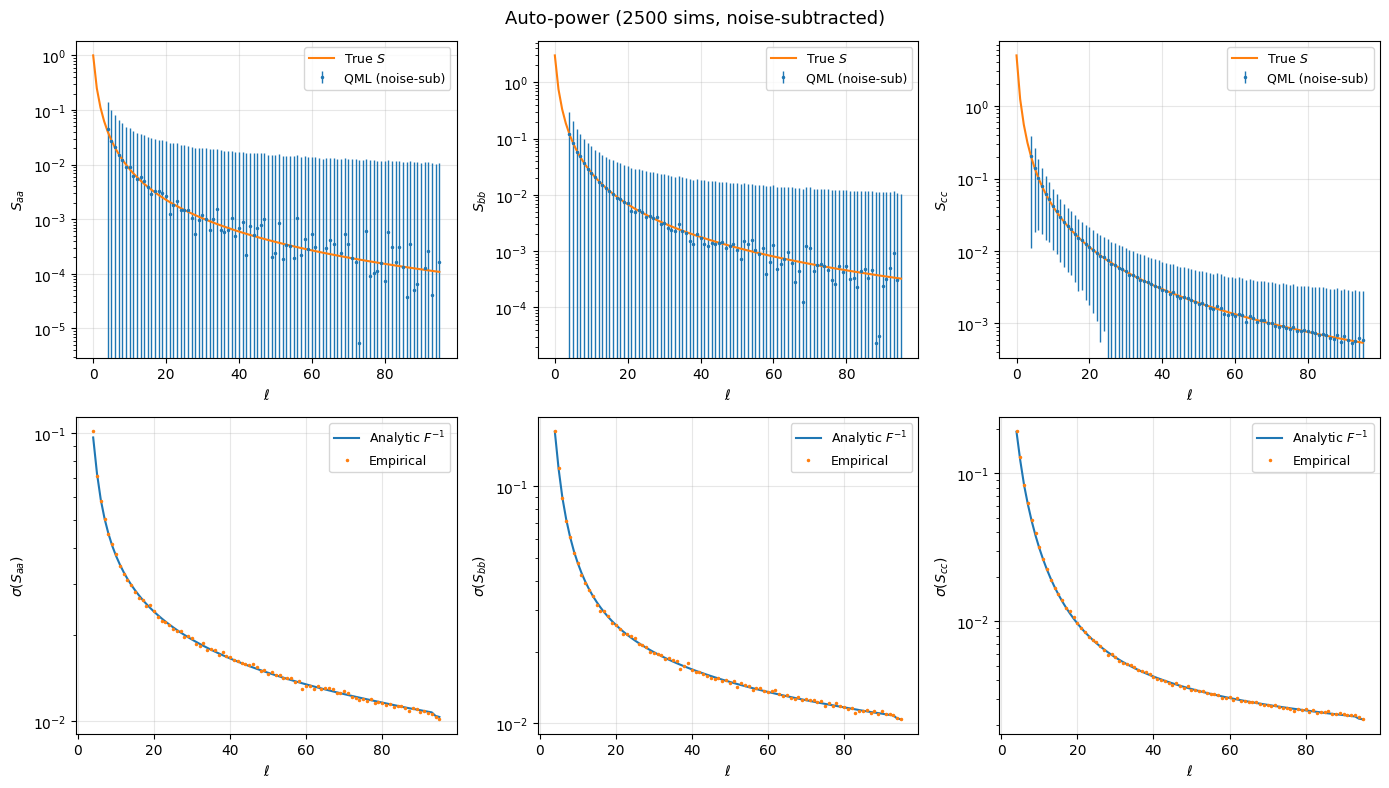

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

spectra = [
    ((0,0), S_aa, r'$S_{aa}$'),
    ((1,1), S_bb, r'$S_{bb}$'),
    ((2,2), S_cc, r'$S_{cc}$'),
]

ells_plot = np.arange(ell0, n_ell)

for col, ((fi, fj), S_true, label) in enumerate(spectra):
    idx = (f_idx[:,0]==fi) & (f_idx[:,1]==fj)

    axs[0, col].errorbar(ells_plot, e_mean[idx],
                         yerr=np.sqrt(np.diag(err_analytic)[idx]),
                         fmt='.', ms=3, lw=1, label='QML (noise-sub)')
    axs[0, col].semilogy(ell, S_true, '-', lw=1.5, label='True $S$')
    axs[0, col].set_xlabel(r'$\ell$')
    axs[0, col].set_ylabel(label)
    axs[0, col].legend(fontsize=9)
    axs[0, col].grid(alpha=0.3)

    sig_an = np.sqrt(np.diag(err_analytic)[idx])
    sig_em = np.sqrt(np.diag(err_empirical)[idx])
    axs[1, col].semilogy(ells_plot, sig_an, '-', lw=1.5, label='Analytic $F^{-1}$')
    axs[1, col].semilogy(ells_plot, sig_em, '.', ms=3, label='Empirical')
    axs[1, col].set_xlabel(r'$\ell$')
    axs[1, col].set_ylabel(f'$\sigma$({label})')
    axs[1, col].legend(fontsize=9)
    axs[1, col].grid(alpha=0.3)

plt.suptitle(f'Auto-power ({n_sims} sims, noise-subtracted)', fontsize=13)
plt.tight_layout()
plt.show()

### 7. Plot cross-power spectra

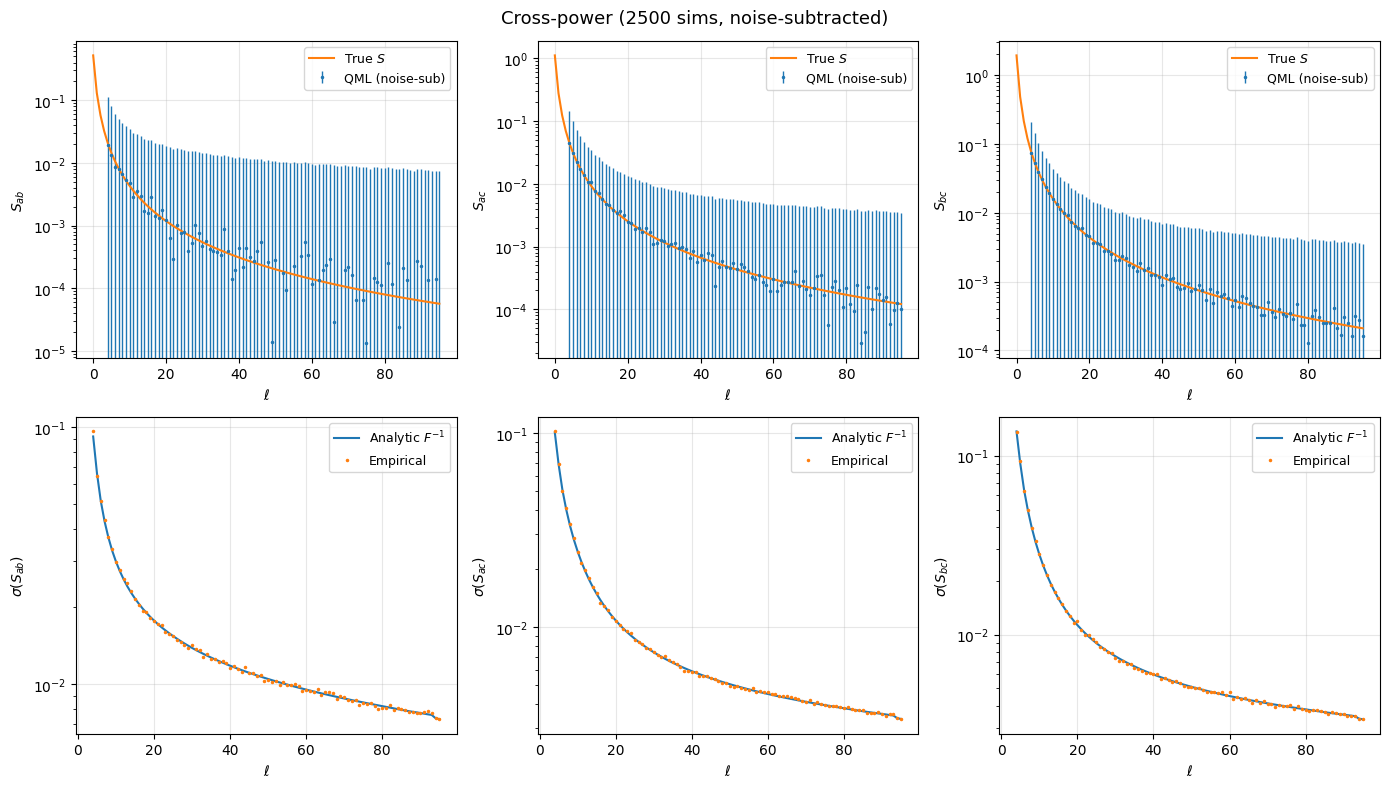

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

cross = [
    ((0,1), S_ab_fid, r'$S_{ab}$'),
    ((0,2), S_ca_fid, r'$S_{ac}$'),
    ((1,2), S_bc_fid, r'$S_{bc}$'),
]

for col, ((fi, fj), S_true, label) in enumerate(cross):
    idx = (f_idx[:,0]==fi) & (f_idx[:,1]==fj)

    axs[0, col].errorbar(ells_plot, e_mean[idx],
                         yerr=np.sqrt(np.diag(err_analytic)[idx]),
                         fmt='.', ms=3, lw=1, label='QML (noise-sub)')
    axs[0, col].semilogy(ell, S_true, '-', lw=1.5, label='True $S$')
    axs[0, col].set_xlabel(r'$\ell$')
    axs[0, col].set_ylabel(label)
    axs[0, col].legend(fontsize=9)
    axs[0, col].grid(alpha=0.3)

    sig_an = np.sqrt(np.diag(err_analytic)[idx])
    sig_em = np.sqrt(np.diag(err_empirical)[idx])
    axs[1, col].semilogy(ells_plot, sig_an, '-', lw=1.5, label='Analytic $F^{-1}$')
    axs[1, col].semilogy(ells_plot, sig_em, '.', ms=3, label='Empirical')
    axs[1, col].set_xlabel(r'$\ell$')
    axs[1, col].set_ylabel(f'$\sigma$({label})')
    axs[1, col].legend(fontsize=9)
    axs[1, col].grid(alpha=0.3)

plt.suptitle(f'Cross-power ({n_sims} sims, noise-subtracted)', fontsize=13)
plt.tight_layout()
plt.show()

### 8. Errorbar ratio (empirical / analytic)

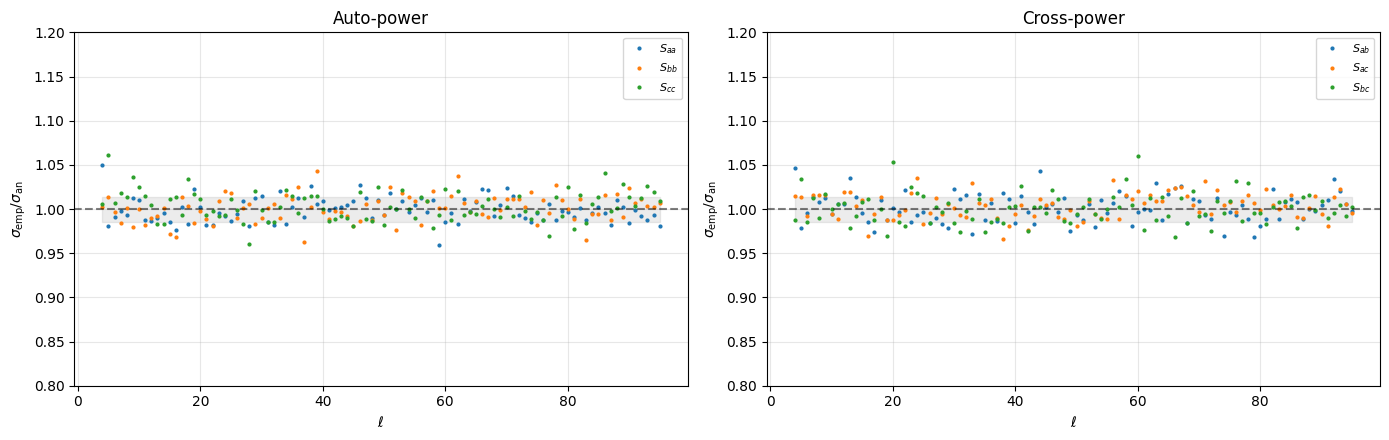

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
ratio_err = 1.0 / np.sqrt(2 * (n_sims - 1))

for ax, spec_list, title in [
    (axs[0], spectra, 'Auto-power'),
    (axs[1], cross, 'Cross-power'),
]:
    for (fi, fj), _, label in spec_list:
        idx = (f_idx[:,0]==fi) & (f_idx[:,1]==fj)
        r = np.sqrt(np.diag(err_empirical)[idx]) / np.sqrt(np.diag(err_analytic)[idx])
        ax.plot(ells_plot, r, '.', ms=4, label=label)
    ax.axhline(1.0, color='k', ls='--', alpha=0.5)
    ax.fill_between(ells_plot, 1-ratio_err, 1+ratio_err, alpha=0.15, color='gray')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\sigma_{\rm emp}/\sigma_{\rm an}$')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.8, 1.2)

plt.tight_layout()
plt.show()